# This notebook contains info on the Dynamical decomposition for JJAS

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sklearn.linear_model import Ridge
import pandas as pd
import os
%matplotlib inline

In [2]:
os.chdir("/home/thappe/HeaT")

from HeaT.dyn_decomp import *

In [3]:
data_path = "/home/thappe/data/"

In [4]:
ls /home/thappe/data/ 

ERA5/       ML_prep_MSLP_STREAM/  T2M_decomposition/  VAE_MODEL/
heatwaves/  NASA_GMST.csv         tf_records/


In [5]:
ls /home/thappe/data/T2M_decomposition

 90th_percentile/
 JJA/
 T2M_dynamic_westEU_LENTIS_june23-sept7_1940-2023_90pctl15d_CDO.nc
 T2M_dynamic_westEU_LENTIS_june23-sept7_1940-2023.nc
 T2M_minus_thermo_westEU_LENTIS_1940-2023.nc
 T2M_minus_thermo_westEU_LENTIS_JA_1940-2023_90pctl15d_CDO.nc
 T2M_minus_thermo_westEU_LENTIS_JA_1940-2023.nc
 T2M_minus_thermo_westEU_LENTIS_june23-sept7_1940-2023_90pctl15d_CDO.nc
 T2M_minus_thermo_westEU_LENTIS_june23-sept7_1940-2023.nc
'T2M_westEU_JJAS_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10.nc'
'T2M_westEU_JJAS_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10_temp_only.nc'
'T2M_westEU_June23-JA-Sept7_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10.nc'
'the410@ada.labs.vu.nl'


In [ ]:
#"T2M_westEU_June23-JA-Sept7_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10.nc"

# To read in the decomposed t2m data 

In [6]:
ls /home/thappe/data/T2M_decomposition/

 90th_percentile/
 JJA/
 T2M_dynamic_westEU_LENTIS_june23-sept7_1940-2023_90pctl15d_CDO.nc
 T2M_dynamic_westEU_LENTIS_june23-sept7_1940-2023.nc
 T2M_minus_thermo_westEU_LENTIS_1940-2023.nc
 T2M_minus_thermo_westEU_LENTIS_JA_1940-2023_90pctl15d_CDO.nc
 T2M_minus_thermo_westEU_LENTIS_JA_1940-2023.nc
 T2M_minus_thermo_westEU_LENTIS_june23-sept7_1940-2023_90pctl15d_CDO.nc
 T2M_minus_thermo_westEU_LENTIS_june23-sept7_1940-2023.nc
'T2M_westEU_JJAS_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10.nc'
'T2M_westEU_JJAS_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10_temp_only.nc'
'T2M_westEU_June23-JA-Sept7_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10.nc'
'the410@ada.labs.vu.nl'


In [7]:
t2m_decomped_file = "T2M_westEU_June23-JA-Sept7_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10.nc"
fileshort = "June 23rd - Sept 7th"

In [8]:
t2m_decom = xr.open_dataset(f"{data_path}/T2M_decomposition/{t2m_decomped_file}")

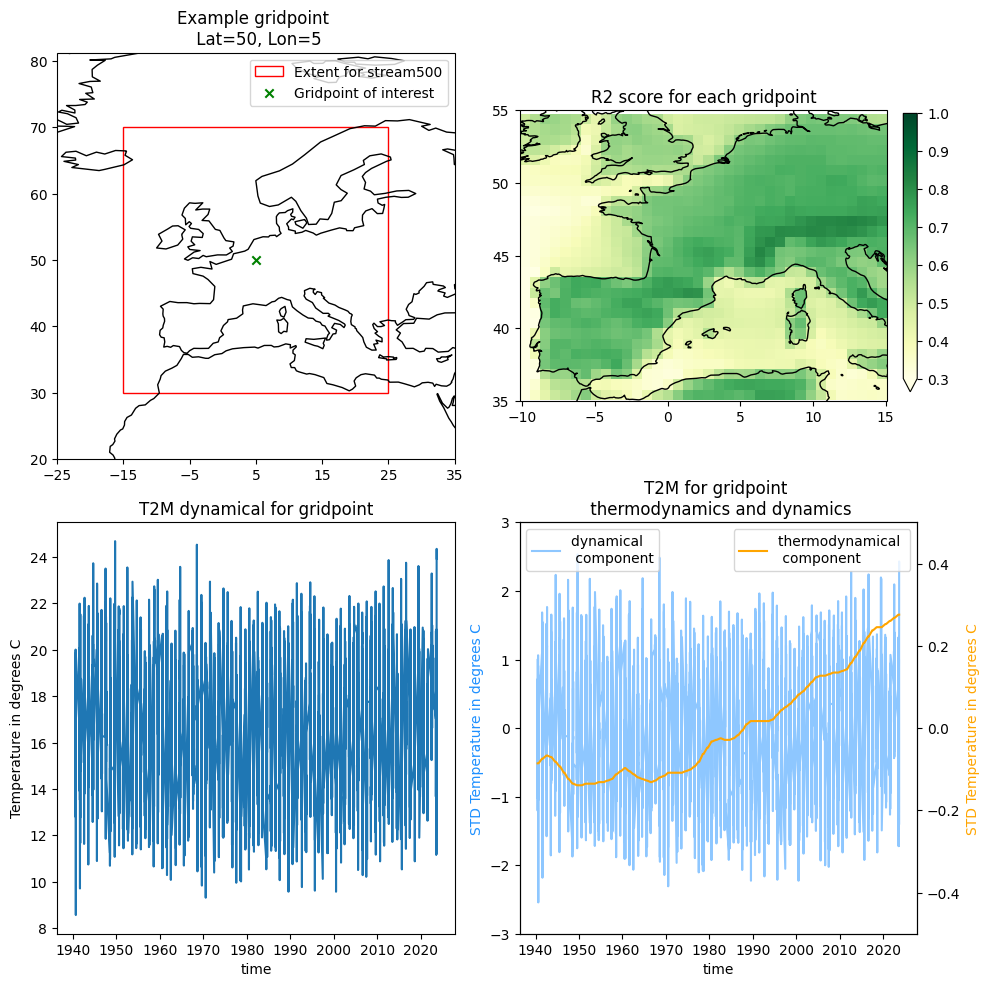

In [9]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
%matplotlib inline

lon, lat = 5, 50
window=20
lon_bounds = (lon-window, lon+window)
lat_bounds = (lat-window, lat+window)


### PLOT

fig = plt.figure(figsize=(10,10))
gs = fig.add_gridspec(6, 6)

ax1 = fig.add_subplot(gs[0:3, 0:3], projection=ccrs.PlateCarree())
size=10
ax1.set_extent([lon-(window+size), lon+(window+size), lat-(window+size), lat+(window+size)])
ax1.add_patch(mpatches.Rectangle(xy=[lon_bounds[0],lat_bounds[0]], width=window*2, height=window*2,
                                facecolor='none', edgecolor='red',
                                transform=ccrs.PlateCarree(), label="Extent for stream500"))
ax1.coastlines()
ax1.scatter(lon,lat, transform=ccrs.PlateCarree(), color='g', marker='x', label="Gridpoint of interest")

ax1.legend()
# ax1.set_title("T2M gridpoint to predict \n and extent for dynamics")
ax1.set_title(f"Example gridpoint \n Lat={lat}, Lon={lon}")
ax1.set_xticks(np.arange(lon-(window+10), lon+(window+10+1), 10))
ax1.set_yticks(np.arange(lat-(window+10), lat+(window+10+1), 10))


####

ax2 = fig.add_subplot(gs[0:3, 3:6], projection=ccrs.PlateCarree())
pc = ax2.pcolormesh(t2m_decom["R2"].longitude,t2m_decom["R2"].latitude,t2m_decom["R2"].values,
                    vmin=0.3, vmax=1, cmap="YlGn") #YlGnBu
fig.colorbar(pc, ax=ax2, fraction=0.035, pad=0.04, extend='min')
ax2.coastlines()
ax2.set_title("R2 score for each gridpoint")
ax2.set_xticks(np.arange(-10, 16, 5))
ax2.set_yticks(np.arange(35, 56, 5))

ax3 = fig.add_subplot(gs[3:6, 0:3])
ax3.plot(t2m_decom["T2M_dynamic"].time, t2m_decom["T2M_dynamic"].sel(latitude=lat, longitude=lon, method="nearest"))
ax3.set_title("T2M dynamical for gridpoint")
ax3.set_xlabel("time")
ax3.set_ylabel("Temperature in degrees C")



ax4 = fig.add_subplot(gs[3:6, 3:6])
ax5 = ax4.twinx()
ax4.plot(t2m_decom["T2M_dynamical_std"].time, t2m_decom["T2M_dynamical_std"].sel(latitude=lat, longitude=lon, method="nearest"), 
         label="dynamical \n component", alpha=0.5, c="dodgerblue")
ax5.plot(t2m_decom["T2M_thermodynamic_std"].time, t2m_decom["T2M_thermodynamic_std"].sel(latitude=lat, longitude=lon, method="nearest"), 
         label="thermodynamical \n component", c="orange")

ax4.set_title("T2M for gridpoint \n thermodynamics and dynamics")
ax4.set_xlabel("time")
ax4.set_ylabel("STD Temperature in degrees C", c="dodgerblue")
ax5.set_ylabel("STD Temperature in degrees C", c="orange")
ax5.set_ylim(-0.5, 0.5)
ax4.set_ylim(-3, 3)
ax4.legend(loc="upper left")
ax5.legend()

# fig.suptitle(f"{fileshort} Lat={lat}, Lon={lon}")
fig.tight_layout()

fig.savefig("/home/thappe/HeaT/Figures/DynDecomp_A1.png", dpi=400)
plt.show()